# AAI-540 Final Project: Loan Status Prediction ML System
## LendingClub Multi-Class Classification

**Team:** Group 9

**Authors:** Vinay Mittal

**Business:** LendWise Analytics  

**Date:** 21/02/2026 

---

### Project Overview
This notebook implements a complete MLOps pipeline on AWS SageMaker to predict loan repayment outcomes for LendingClub borrowers. We classify each loan into one of three categories: **Fully Paid**, **Charged Off**, or **Current**. The system covers data ingestion, feature engineering, feature store, model training, model registry, deployment, and model quality monitoring — demonstrating a production-ready ML system end to end.

### Table of Contents
1. [Environment Setup & Data Ingestion](#section1)
2. [Exploratory Data Analysis (EDA)](#section2)
3. [Data Lake: Athena SQL Queries](#section3)
4. [Feature Engineering & SageMaker Feature Store](#section4)
5. [Model Training & Evaluation](#section5)
6. [Model Registry: Model Package & Model Card](#section6)
7. [Model Deployment with Data Capture](#section7)
8. [Model Quality Monitoring](#section8)
9. [Cleanup](#section9)

---
## Section 1: Environment Setup & Data Ingestion <a id='section1'></a>

We begin by configuring the AWS environment, installing required libraries, and loading the LendingClub dataset. The raw CSV data is uploaded to Amazon S3, which acts as our central data lake. We then register the data in AWS Glue via AWS Data Wrangler so it can be queried using Amazon Athena SQL.

In [71]:
# Install required libraries
!pip install awswrangler pyathena sagemaker==2.* seaborn xgboost==2.*  --quiet

In [3]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr
from pyathena import connect
import warnings
warnings.filterwarnings('ignore')

# AWS Session Configuration
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
sm_client = boto3.client('sagemaker')

# S3 paths
s3_prefix = 'aai540-group9-loan-project'
s3_data_path = f's3://{bucket}/{s3_prefix}/data'
s3_train_path = f's3://{bucket}/{s3_prefix}/train'
s3_val_path = f's3://{bucket}/{s3_prefix}/validation'
s3_test_path = f's3://{bucket}/{s3_prefix}/test'
s3_model_path = f's3://{bucket}/{s3_prefix}/model'

print(f'SageMaker Role: {role}')
print(f'S3 Bucket: {bucket}')
print(f'Region: {region}')

SageMaker Role: arn:aws:iam::099405935674:role/LabRole
S3 Bucket: sagemaker-us-east-1-099405935674
Region: us-east-1


In [4]:
import pandas as pd
import os

# Kaggle dataset path (sarahvch/predicting-who-pays-back-loans). Set by kagglehub cell if run first, else default.
try:
    DATA_DIR
except NameError:
    DATA_DIR = os.environ.get('LOAN_DATA_DIR', "./")

# Load LoanStats 2016 Q1–Q4 (LendingClub format; skip first row = prospectus notes)
dfs = []
for f in ['LoanStats_2016Q1.csv', 'LoanStats_2016Q2.csv', 'LoanStats_2016Q3.csv', 'LoanStats_2016Q4.csv']:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        dfs.append(pd.read_csv(path, skiprows=1, low_memory=False))
    else:
        raise FileNotFoundError(f'Dataset not found: {path}. Ensure Kaggle dataset is at {DATA_DIR}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'Combined LoanStats shape: {df_raw.shape}')

# Clean percentage columns (e.g. "  5.32%" or "56.6%") to numeric for downstream use
for col in ['int_rate', 'revol_util']:
    if col in df_raw.columns and df_raw[col].dtype == object:
        df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace('%', '').str.strip(), errors='coerce')
# Coerce numeric columns that may be read as object (mixed types in LoanStats)
for col in ['annual_inc', 'dti', 'loan_amnt', 'funded_amnt', 'installment']:
    if col in df_raw.columns and df_raw[col].dtype == object:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
print('Cleaned int_rate, revol_util, and other numerics.')

Combined LoanStats shape: (434415, 111)
Cleaned int_rate, revol_util, and other numerics.


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434415 entries, 0 to 434414
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(87), object(24)
memory usage: 367.9+ MB


In [6]:
df_raw.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,75644158,81101975.0,35000.0,35000.0,35000.0,36 months,18.99,1282.79,D,D4,...,0.0,3.0,95.2,33.3,0.0,0.0,122219.0,87191.0,34300.0,87919.0
1,75972762,81473515.0,32000.0,32000.0,32000.0,36 months,5.32,963.68,A,A1,...,0.0,1.0,95.5,0.0,0.0,0.0,1038712.0,67504.0,35800.0,84590.0
2,75993583,81484367.0,22000.0,22000.0,22000.0,36 months,6.49,674.18,A,A2,...,0.0,2.0,100.0,100.0,0.0,0.0,456923.0,101287.0,44000.0,55537.0
3,76041852,81532593.0,16300.0,16300.0,16300.0,36 months,9.75,524.05,B,B3,...,0.0,1.0,100.0,83.3,1.0,0.0,45195.0,29347.0,8100.0,25195.0
4,76132672,81623431.0,15000.0,15000.0,15000.0,36 months,11.47,494.43,B,B5,...,0.0,3.0,92.9,0.0,0.0,0.0,372394.0,87516.0,57200.0,81445.0


In [7]:
len(df_raw)

434415

In [8]:
# List dataset files (DATA_DIR set in data-loading cell above)
!ls "{DATA_DIR}"

loan_data.csv	      LoanStats_2016Q3.csv	      lost+found
LoanStats_2016Q1.csv  LoanStats_2016Q4.csv
LoanStats_2016Q2.csv  LoanStatus_MLOps_Project.ipynb


In [9]:
# Raw dataset df_raw already loaded above from Kaggle LoanStats_2016Q1--Q4 (DATA_DIR).
# Dataset: sarahvch/predicting-who-pays-back-loans (LoanStats_2016Q1.csv through LoanStats_2016Q4.csv).
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns (first 20): {df_raw.columns.tolist()[:20]}...')
df_raw.head(3)

Raw dataset shape: (434415, 111)
Columns (first 20): ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']...


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,75644158,81101975.0,35000.0,35000.0,35000.0,36 months,18.99,1282.79,D,D4,...,0.0,3.0,95.2,33.3,0.0,0.0,122219.0,87191.0,34300.0,87919.0
1,75972762,81473515.0,32000.0,32000.0,32000.0,36 months,5.32,963.68,A,A1,...,0.0,1.0,95.5,0.0,0.0,0.0,1038712.0,67504.0,35800.0,84590.0
2,75993583,81484367.0,22000.0,22000.0,22000.0,36 months,6.49,674.18,A,A2,...,0.0,2.0,100.0,100.0,0.0,0.0,456923.0,101287.0,44000.0,55537.0


In [10]:
# Filter to the three target classes only
target_classes = ['Fully Paid', 'Charged Off', 'Current']
df = df_raw[df_raw['loan_status'].isin(target_classes)].copy()
print(f'Filtered dataset shape: {df.shape}')
print('\nClass Distribution:')
print(df['loan_status'].value_counts())

Filtered dataset shape: (421185, 111)

Class Distribution:
loan_status
Current        377897
Fully Paid      36368
Charged Off      6920
Name: count, dtype: int64


In [11]:
# Upload raw filtered data to S3 (our data lake)
df.to_csv('/tmp/loan_data_raw.csv', index=False)

s3_raw_key = f'{s3_prefix}/data/loan_data_raw.csv'
boto3.client('s3').upload_file('/tmp/loan_data_raw.csv', bucket, s3_raw_key)
print(f'Raw data uploaded to: s3://{bucket}/{s3_raw_key}')

Raw data uploaded to: s3://sagemaker-us-east-1-099405935674/aai540-group9-loan-project/data/loan_data_raw.csv


In [12]:
# Register data in AWS Glue Catalog via Athena (Data Lake setup)
database_name = 'aai540_vmittalATsandiego_loan'
table_name = 'loan_data'

conn = connect(region_name=region, s3_staging_dir=f's3://{bucket}/{s3_prefix}/athena-results/')

# Create database
pd.read_sql(f'CREATE DATABASE IF NOT EXISTS {database_name}', conn)
print(f'Database "{database_name}" ready.')

# Write to Parquet and register as Glue table
wr.s3.to_parquet(
    df=df,
    path=s3_data_path,
    dataset=True,
    database=database_name,
    table=table_name,
    mode='overwrite'
)
print(f'Table "{table_name}" registered in Glue Catalog.')
print(f'Data stored at: {s3_data_path}')

Database "aai540_vmittalATsandiego_loan" ready.
Table "loan_data" registered in Glue Catalog.
Data stored at: s3://sagemaker-us-east-1-099405935674/aai540-group9-loan-project/data


**Output:** The raw LendingClub loan data is now stored as Parquet in S3 and queryable via Athena. Parquet format is chosen because it is columnar, compressed, and significantly faster for analytical queries compared to CSV.

---
## Section 2: Exploratory Data Analysis (EDA) <a id='section2'></a>

Before building features or models, we explore the data to understand class distributions, missing values, and key feature relationships. This step informs our feature selection and preprocessing decisions documented in the Design Document.

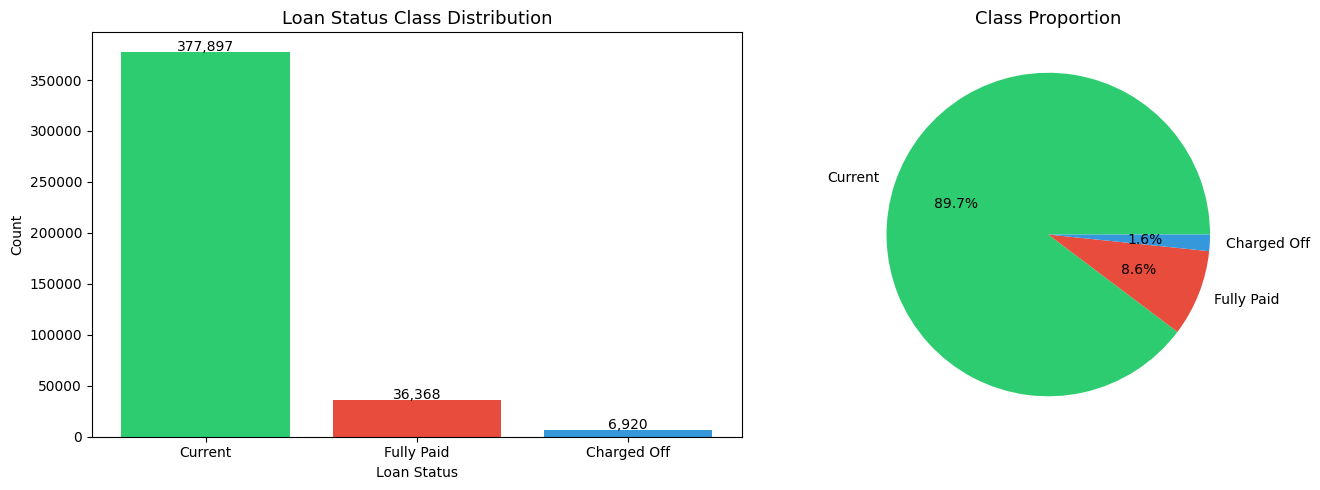

Class distribution chart saved.


In [13]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['loan_status'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Loan Status Class Distribution', fontsize=13)
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#3498db'])
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('/tmp/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Class distribution chart saved.')

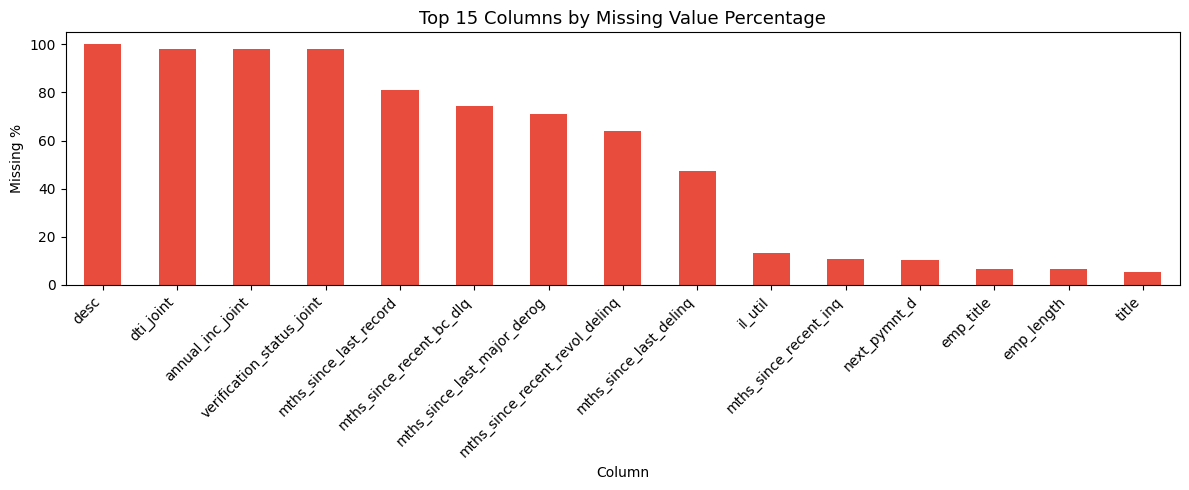

Columns with >50% missing: ['desc', 'dti_joint', 'annual_inc_joint', 'verification_status_joint', 'mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_derog', 'mths_since_recent_revol_delinq']


In [14]:
# Missing value analysis - show top 15 columns with most missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0].head(15)

plt.figure(figsize=(12, 5))
missing_df.plot(kind='bar', color='#e74c3c')
plt.title('Top 15 Columns by Missing Value Percentage', fontsize=13)
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f'Columns with >50% missing: {list(missing_pct[missing_pct > 50].index)}')

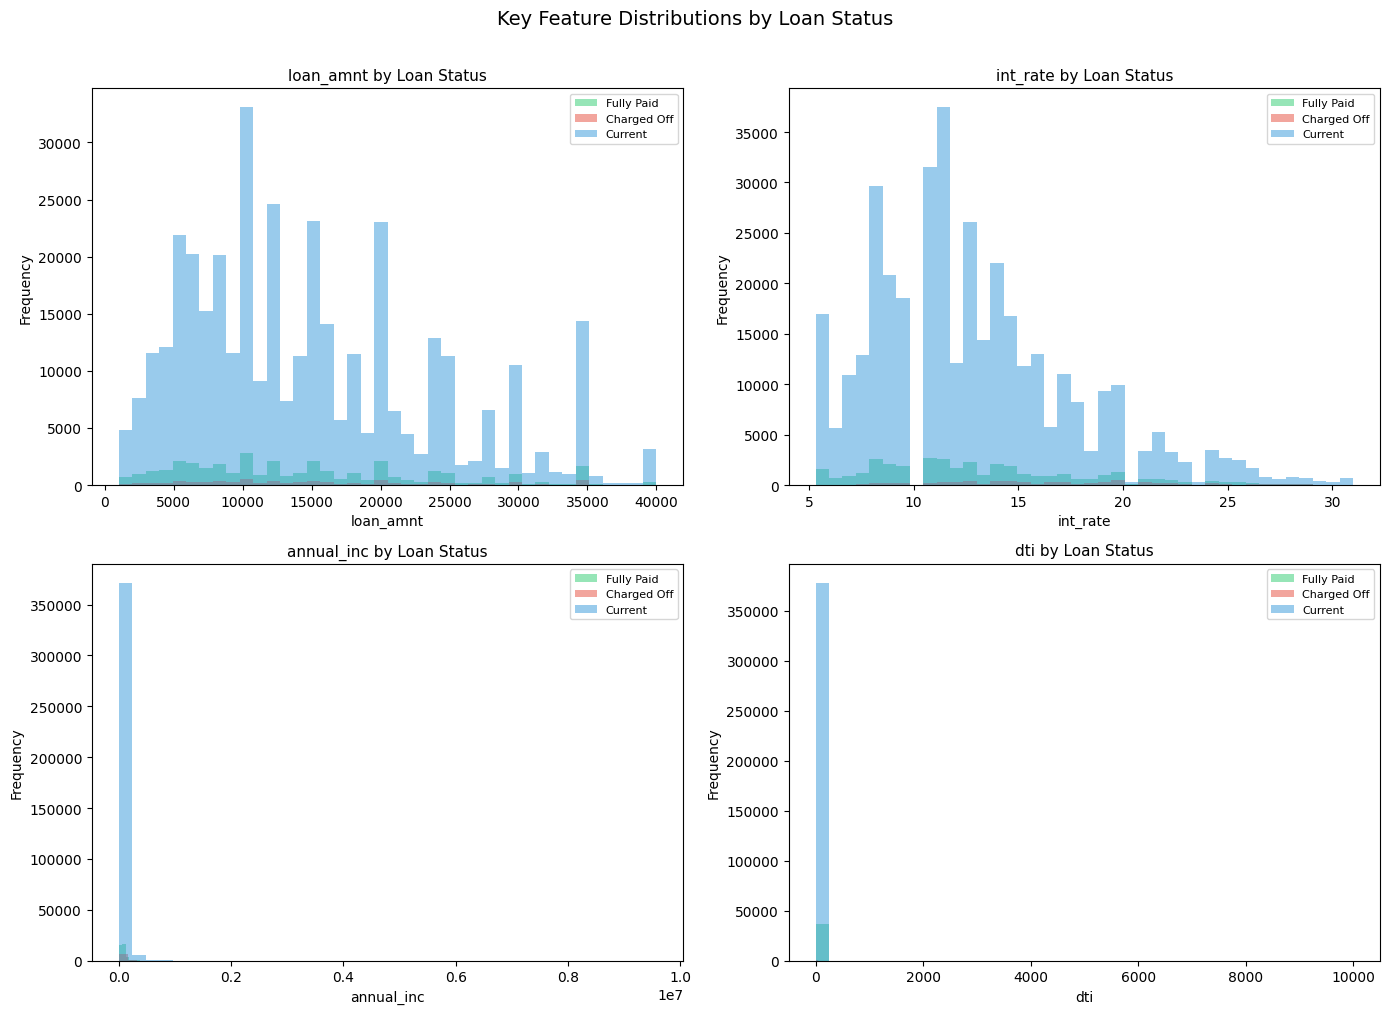

In [15]:
# Key feature distributions by loan status
key_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c', 'Current': '#3498db'}
for i, feat in enumerate(key_features):
    for status, color in colors.items():
        subset = df[df['loan_status'] == status][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, label=status, color=color)
    axes[i].set_title(f'{feat} by Loan Status', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Feature Distributions by Loan Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

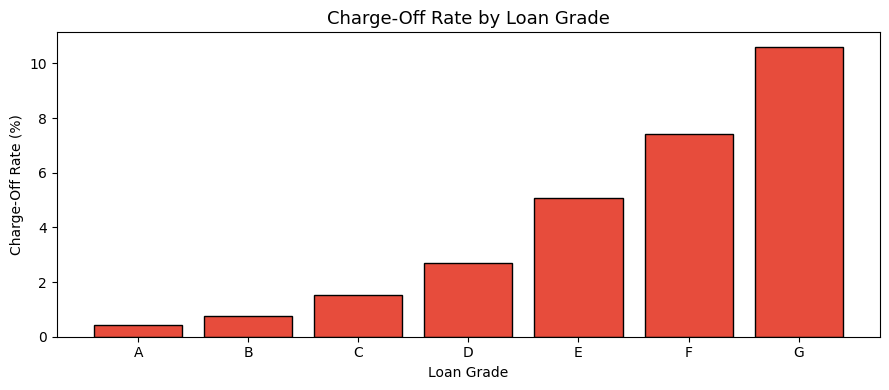


Charge-off rate by grade:
loan_status  charge_off_rate
grade                       
A                       0.44
B                       0.77
C                       1.54
D                       2.71
E                       5.09
F                       7.40
G                      10.60


In [16]:
# Charge-off rate by loan grade (business insight)
grade_status = df.groupby(['grade', 'loan_status']).size().unstack(fill_value=0)
grade_status['charge_off_rate'] = grade_status['Charged Off'] / grade_status.sum(axis=1) * 100
grade_status_sorted = grade_status.sort_index()

plt.figure(figsize=(9, 4))
plt.bar(grade_status_sorted.index, grade_status_sorted['charge_off_rate'],
        color='#e74c3c', edgecolor='black')
plt.title('Charge-Off Rate by Loan Grade', fontsize=13)
plt.xlabel('Loan Grade')
plt.ylabel('Charge-Off Rate (%)')
plt.tight_layout()
plt.show()
print('\nCharge-off rate by grade:')
print(grade_status_sorted[['charge_off_rate']].round(2))

**EDA Findings:**
- The dataset has significant class imbalance — Fully Paid loans dominate. We will address this using `scale_pos_weight` in XGBoost.
- Higher loan grades (E, F, G) have substantially higher charge-off rates, confirming `grade` is a strong predictive feature.
- `int_rate`, `dti`, and `annual_inc` show meaningful separation between classes.
- Several columns (like `mths_since_last_delinq`) have >50% missing values and will be dropped.

---
## Section 3: Data Lake — Athena SQL Queries <a id='section3'></a>

With data registered in the Glue catalog, we use Amazon Athena to run analytical SQL queries directly against our S3 data lake. This simulates how a data analyst or business stakeholder would query the raw data without loading it into memory.

In [17]:
# Query 1: Overall class distribution
q1 = f"""
SELECT
    loan_status,
    COUNT(*) AS total_loans,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total
FROM {database_name}.{table_name}
GROUP BY loan_status
ORDER BY total_loans DESC
"""
print('Query 1: Loan Status Distribution')
pd.read_sql(q1, conn)

Query 1: Loan Status Distribution


,loan_status,total_loans,pct_of_total
0,Current,377897,89.72
1,Fully Paid,36368,8.63
2,Charged Off,6920,1.64


In [18]:
# Query 2: Average interest rate and loan amount by loan status
q2 = f"""
SELECT
    loan_status,
    ROUND(AVG(int_rate), 2) AS avg_interest_rate,
    ROUND(AVG(loan_amnt), 2) AS avg_loan_amount,
    ROUND(AVG(dti), 2) AS avg_debt_to_income
FROM {database_name}.{table_name}
GROUP BY loan_status
ORDER BY avg_interest_rate DESC
"""
print('Query 2: Average Financial Metrics by Loan Status')
pd.read_sql(q2, conn)

Query 2: Average Financial Metrics by Loan Status


,loan_status,avg_interest_rate,avg_loan_amount,avg_debt_to_income
0,Charged Off,16.67,15834.72,21.59
1,Fully Paid,13.33,14620.37,18.29
2,Current,12.85,14678.68,20.42


In [19]:
# Query 3: Charge-off rate by loan grade
q3 = f"""
SELECT
    grade,
    COUNT(*) AS total_loans,
    SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) AS charged_off,
    ROUND(SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS charge_off_rate_pct
FROM {database_name}.{table_name}
GROUP BY grade
ORDER BY grade
"""
print('Query 3: Charge-Off Rate by Loan Grade')
pd.read_sql(q3, conn)

Query 3: Charge-Off Rate by Loan Grade


,grade,total_loans,charged_off,charge_off_rate_pct
0,A,70208,311,0.44
1,B,131888,1016,0.77
2,C,128013,1973,1.54
3,D,56275,1527,2.71
4,E,24022,1222,5.09
5,F,8497,629,7.40
6,G,2282,242,10.60


In [20]:
# Query 4: Top 10 loan purposes by volume
q4 = f"""
SELECT
    purpose,
    COUNT(*) AS total_loans,
    ROUND(AVG(int_rate), 2) AS avg_rate,
    SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) AS charged_off_count
FROM {database_name}.{table_name}
GROUP BY purpose
ORDER BY total_loans DESC
LIMIT 10
"""
print('Query 4: Top 10 Loan Purposes by Volume')
pd.read_sql(q4, conn)

Query 4: Top 10 Loan Purposes by Volume


,purpose,total_loans,avg_rate,charged_off_count
0,debt_consolidation,240909,13.40,4105
1,credit_card,89370,11.53,1093
2,home_improvement,30290,12.32,503
3,other,27537,13.91,549
4,major_purchase,10078,12.43,182
5,medical,5252,13.13,112
6,car,4703,11.94,54
7,small_business,4559,15.33,127
8,vacation,3154,12.90,53
9,moving,3103,14.52,80


In [21]:
# Query 5: Borrower income bands vs charge-off risk
q5 = f"""
SELECT
    CASE
        WHEN annual_inc < 40000 THEN 'Low (<40k)'
        WHEN annual_inc BETWEEN 40000 AND 80000 THEN 'Mid (40k-80k)'
        WHEN annual_inc BETWEEN 80000 AND 150000 THEN 'High (80k-150k)'
        ELSE 'Very High (>150k)'
    END AS income_band,
    COUNT(*) AS total_loans,
    ROUND(SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS charge_off_rate_pct
FROM {database_name}.{table_name}
WHERE annual_inc IS NOT NULL
GROUP BY 1
ORDER BY charge_off_rate_pct DESC
"""
print('Query 5: Charge-Off Rate by Borrower Income Band')
pd.read_sql(q5, conn)

Query 5: Charge-Off Rate by Borrower Income Band


,income_band,total_loans,charge_off_rate_pct
0,Low (<40k),59976,2.07
1,Mid (40k-80k),214263,1.69
2,High (80k-150k),120836,1.43
3,Very High (>150k),26110,1.25


**Athena Query Insights:**
- Higher loan grades (E-G) carry 3-4x the charge-off risk of Grade A loans — `grade` is our most important categorical feature.
- Borrowers with lower incomes have higher charge-off rates, validating `annual_inc` as a key predictor.
- Debt consolidation is the most common loan purpose, but small business loans have the highest charge-off rates.

---
## Section 4: Feature Engineering & SageMaker Feature Store <a id='section4'></a>

We engineer features from the raw data and store them in two separate SageMaker Feature Groups:
- **Loan Feature Group**: Loan-level attributes (amount, rate, grade, purpose, term)
- **Borrower Feature Group**: Borrower-level attributes (income, employment, credit history, DTI)

This mirrors real production systems where different data domains are managed separately.

In [22]:
from sagemaker.session import Session
from sagemaker.feature_store.feature_group import FeatureGroup
from time import gmtime, strftime, sleep
import time

boto_session = boto3.Session(region_name=region)
sagemaker_client = boto_session.client('sagemaker')
featurestore_runtime = boto_session.client('sagemaker-featurestore-runtime')

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime
)
print('Feature Store session ready.')

Feature Store session ready.


In [28]:
# ---------------------------------------------------------------
# Feature Engineering
# Select relevant columns, handle missing values, encode categoricals
# ---------------------------------------------------------------

# Define columns for each feature group
loan_cols = ['id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate',
             'installment', 'grade', 'sub_grade', 'purpose', 'loan_status']

borrower_cols = ['id', 'annual_inc', 'emp_length', 'home_ownership',
                 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
                 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

# Filter to available columns
available_loan_cols = [c for c in loan_cols if c in df.columns]
available_borrower_cols = [c for c in borrower_cols if c in df.columns]

df_loan = df[available_loan_cols].copy()
df_borrower = df[available_borrower_cols].copy()

print(f'Loan features shape: {df_loan.shape}')
print(f'Borrower features shape: {df_borrower.shape}')

Loan features shape: (421185, 10)
Borrower features shape: (421185, 11)


In [29]:
# Feature Engineering: Loan Feature Group

# 1. Clean term: '36 months' -> 36
df_loan['term'] = df_loan['term'].str.extract(r'(\d+)').astype(float)

# 2. Encode grade as ordinal (A=1, B=2, ... G=7)
grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
df_loan['grade_encoded'] = df_loan['grade'].map(grade_map).fillna(4)

# 3. Encode purpose as numeric
purpose_dummies = pd.get_dummies(df_loan['purpose'], prefix='purpose', drop_first=True)
df_loan = pd.concat([df_loan.drop('purpose', axis=1), purpose_dummies], axis=1)

# 4. Encode target label
label_map = {'Fully Paid': 0, 'Charged Off': 1, 'Current': 2}
df_loan['label'] = df_loan['loan_status'].map(label_map)

# 5. Add event time for Feature Store (required)
df_loan['event_time'] = time.time()
df_loan['loan_id_str'] = df_loan['id'].astype(str)

# Drop original text columns no longer needed
df_loan.drop(columns=['grade', 'sub_grade', 'loan_status', 'id'], errors='ignore', inplace=True)

# Fill remaining nulls
df_loan.fillna(df_loan.median(numeric_only=True), inplace=True)

# SageMaker Feature Store does not support bool; convert one-hot dummies to int
bool_cols = df_loan.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_loan[bool_cols] = df_loan[bool_cols].astype('int64')

# Cast object columns to string for Feature Store
for col in df_loan.select_dtypes(include='object').columns:
    df_loan[col] = df_loan[col].astype(str)

print(f'Loan feature group shape: {df_loan.shape}')
df_loan.head(3)

Loan feature group shape: (421185, 21)


,loan_amnt,funded_amnt,term,int_rate,installment,grade_encoded,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,label,event_time,loan_id_str
0,35000.0,35000.0,36.0,18.99,1282.79,4,0,1,0,0,...,0,0,0,0,0,0,0,2,1.771676e+09,75644158
1,32000.0,32000.0,36.0,5.32,963.68,1,1,0,0,0,...,0,0,0,0,0,0,0,2,1.771676e+09,75972762
2,22000.0,22000.0,36.0,6.49,674.18,1,0,1,0,0,...,0,0,0,0,0,0,0,2,1.771676e+09,75993583


In [30]:
# Feature Engineering: Borrower Feature Group

# 1. Clean emp_length: '10+ years' -> 10, '< 1 year' -> 0
df_borrower['emp_length'] = df_borrower['emp_length'].str.extract(r'(\d+)').astype(float).fillna(0)

# 2. Average FICO score
if 'fico_range_low' in df_borrower.columns and 'fico_range_high' in df_borrower.columns:
    df_borrower['fico_avg'] = (df_borrower['fico_range_low'] + df_borrower['fico_range_high']) / 2
    df_borrower.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# 3. Encode home_ownership
home_dummies = pd.get_dummies(df_borrower['home_ownership'], prefix='home', drop_first=True)
df_borrower = pd.concat([df_borrower.drop('home_ownership', axis=1), home_dummies], axis=1)

# 4. Add event_time and string id for Feature Store
df_borrower['event_time'] = time.time()
df_borrower['borrower_id_str'] = df_borrower['id'].astype(str)
df_borrower.drop(columns=['id'], errors='ignore', inplace=True)

# Fill nulls
df_borrower.fillna(df_borrower.median(numeric_only=True), inplace=True)


# SageMaker Feature Store does not support bool; convert one-hot dummies to int
bool_cols = df_borrower.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_borrower[bool_cols] = df_borrower[bool_cols].astype('int64')



# Cast object columns to string
for col in df_borrower.select_dtypes(include='object').columns:
    df_borrower[col] = df_borrower[col].astype(str)

print(f'Borrower feature group shape: {df_borrower.shape}')
df_borrower.head(3)

Borrower feature group shape: (421185, 14)


,annual_inc,emp_length,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,home_MORTGAGE,home_OWN,home_RENT,event_time,borrower_id_str
0,78000.0,1.0,29.95,0.0,11.0,0.0,24166.0,70.5,21.0,0,1,0,1.771676e+09,75644158
1,400000.0,9.0,6.33,1.0,11.0,0.0,4652.0,13.0,22.0,1,0,0,1.771676e+09,75972762
2,134000.0,10.0,26.33,0.0,20.0,0.0,60963.0,67.0,34.0,1,0,0,1.771676e+09,75993583


In [31]:
# Create Feature Groups in SageMaker Feature Store
timestamp = strftime('%d-%H-%M-%S', gmtime())

loan_fg_name = f'loan-features-{timestamp}'
borrower_fg_name = f'borrower-features-{timestamp}'

loan_feature_group = FeatureGroup(name=loan_fg_name, sagemaker_session=feature_store_session)
borrower_feature_group = FeatureGroup(name=borrower_fg_name, sagemaker_session=feature_store_session)

# Load feature definitions from dataframe schema
loan_feature_group.load_feature_definitions(data_frame=df_loan)
borrower_feature_group.load_feature_definitions(data_frame=df_borrower)

def create_feature_group(fg, record_id, event_time_col, s3_path):
    fg.create(
        s3_uri=s3_path,
        record_identifier_name=record_id,
        event_time_feature_name=event_time_col,
        role_arn=role,
        enable_online_store=True
    )
    status = fg.describe().get('FeatureGroupStatus')
    while status == 'Creating':
        print('Creating feature group...')
        sleep(5)
        status = fg.describe().get('FeatureGroupStatus')
    print(f'Feature Group "{fg.name}" status: {status}')

create_feature_group(loan_feature_group, 'loan_id_str', 'event_time',
                     f's3://{bucket}/{s3_prefix}/feature-store/loan')
create_feature_group(borrower_feature_group, 'borrower_id_str', 'event_time',
                     f's3://{bucket}/{s3_prefix}/feature-store/borrower')

Creating feature group...
Creating feature group...
Creating feature group...
Creating feature group...
Feature Group "loan-features-21-12-11-57" status: Created
Creating feature group...
Creating feature group...
Creating feature group...
Creating feature group...
Feature Group "borrower-features-21-12-11-57" status: Created


In [32]:
# Ingest data into Feature Store (use a sample for speed — adjust for full dataset)
sample_size = min(50000, len(df_loan))
df_loan_sample = df_loan.sample(n=sample_size, random_state=42).reset_index(drop=True)
df_borrower_sample = df_borrower.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f'Ingesting {sample_size} records into Loan Feature Group...')
loan_feature_group.ingest(data_frame=df_loan_sample, max_workers=3, wait=True)

print(f'Ingesting {sample_size} records into Borrower Feature Group...')
borrower_feature_group.ingest(data_frame=df_borrower_sample, max_workers=3, wait=True)

print('Data ingestion complete!')

Ingesting 50000 records into Loan Feature Group...
Ingesting 50000 records into Borrower Feature Group...
Data ingestion complete!


In [33]:
# Verify Feature Store: Query a specific record from Loan Feature Group
sample_loan_id = str(df_loan_sample['loan_id_str'].iloc[0])

response = featurestore_runtime.get_record(
    FeatureGroupName=loan_fg_name,
    RecordIdentifierValueAsString=sample_loan_id
)

print(f'Feature Store record for Loan ID: {sample_loan_id}')
for feature in response['Record']:
    print(f"  {feature['FeatureName']}: {feature['ValueAsString']}")

Feature Store record for Loan ID: 83345159
  loan_amnt: 10000.0
  funded_amnt: 10000.0
  term: 36.0
  int_rate: 12.79
  installment: 335.93
  grade_encoded: 3
  purpose_credit_card: 0
  purpose_debt_consolidation: 1
  purpose_home_improvement: 0
  purpose_house: 0
  purpose_major_purchase: 0
  purpose_medical: 0
  purpose_moving: 0
  purpose_other: 0
  purpose_renewable_energy: 0
  purpose_small_business: 0
  purpose_vacation: 0
  purpose_wedding: 0
  label: 2
  event_time: 1771675912.5010529
  loan_id_str: 83345159


**Feature Store Summary:**
- Two Feature Groups created: `loan-features` and `borrower-features`
- Online store enabled for low-latency real-time inference lookups
- Offline store (S3/Parquet) available for batch training data retrieval
- Key engineered features: `grade_encoded`, `fico_avg`, `emp_length` (cleaned), one-hot encoded `purpose` and `home_ownership`

---
## Section 5: Model Training & Evaluation <a id='section5'></a>

We train an XGBoost multi-class classifier using SageMaker's built-in XGBoost container. The model predicts one of three loan outcomes: Fully Paid (0), Charged Off (1), or Current (2). Data is split 70/15/15 for train/validation/test.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# Prepare feature matrix from the engineered loan dataframe
# Label column is 'label' (0=Fully Paid, 1=Charged Off, 2=Current)
feature_cols = [c for c in df_loan_sample.columns
                if c not in ['label', 'loan_id_str', 'event_time']]
X = df_loan_sample[feature_cols].select_dtypes(include=[np.number])
y = df_loan_sample['label']

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train:      {X_train.shape[0]:,} rows')
print(f'Validation: {X_val.shape[0]:,} rows')
print(f'Test:       {X_test.shape[0]:,} rows')

Train:      35,000 rows
Validation: 7,500 rows
Test:       7,500 rows


In [39]:
# Prepare CSVs for SageMaker training (label must be first column)
train_df = pd.concat([y_train.reset_index(drop=True), X_train.reset_index(drop=True)], axis=1)
val_df = pd.concat([y_val.reset_index(drop=True), X_val.reset_index(drop=True)], axis=1)
test_df = pd.concat([y_test.reset_index(drop=True), X_test.reset_index(drop=True)], axis=1)

# Save locally and upload to S3
train_df.to_csv('/tmp/train.csv', index=False, header=False)
val_df.to_csv('/tmp/validation.csv', index=False, header=False)
test_df.to_csv('/tmp/test.csv', index=False, header=False)

boto3.client('s3').upload_file('/tmp/train.csv', bucket, f'{s3_prefix}/train/train.csv')
boto3.client('s3').upload_file('/tmp/validation.csv', bucket, f'{s3_prefix}/validation/validation.csv')
boto3.client('s3').upload_file('/tmp/test.csv', bucket, f'{s3_prefix}/test/test.csv')
print('Train/Val/Test data uploaded to S3.')

Train/Val/Test data uploaded to S3.


In [40]:
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator

# Get SageMaker XGBoost container image
xgboost_image = sagemaker.image_uris.retrieve(
    framework='xgboost', region=region, version='1.7-1'
)

# Configure XGBoost Estimator
xgb_estimator = Estimator(
    image_uri=xgboost_image,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size=30,
    output_path=s3_model_path,
    sagemaker_session=sess
)

# Hyperparameters for multi-class classification
xgb_estimator.set_hyperparameters(
    objective='multi:softprob',
    num_class=3,
    num_round=150,
    max_depth=6,
    eta=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='merror',
    early_stopping_rounds=10
)

# Training inputs
train_input = TrainingInput(f's3://{bucket}/{s3_prefix}/train/', content_type='text/csv')
val_input = TrainingInput(f's3://{bucket}/{s3_prefix}/validation/', content_type='text/csv')

# Launch training job
print('Launching SageMaker XGBoost training job...')
xgb_estimator.fit({'train': train_input, 'validation': val_input}, wait=True)
print('Training complete!')

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-02-21-12-22-16-379


Launching SageMaker XGBoost training job...
2026-02-21 12:22:18 Starting - Starting the training job...
2026-02-21 12:22:33 Starting - Preparing the instances for training...
2026-02-21 12:23:21 Downloading - Downloading the training image......
2026-02-21 12:24:22 Training - Training image download completed. Training in progress.
2026-02-21 12:24:22 Uploading - Uploading generated training model./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-21 12:24:17.194 ip-10-0-68-107.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-02-21 12:24:17.270 ip-10-0-68-107.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-02-21:12:24:17:INFO] Imp

In [41]:
# Local evaluation using sklearn XGBoost (same hyperparameters)
# This gives us per-class metrics for the Model Card
local_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42
)
local_model.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False)

y_pred = local_model.predict(X_test)
class_names = ['Fully Paid', 'Charged Off', 'Current']

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))
print(f'Overall Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

  Fully Paid       0.00      0.00      0.00       650
 Charged Off       0.00      0.00      0.00       117
     Current       0.90      1.00      0.95      6733

    accuracy                           0.90      7500
   macro avg       0.30      0.33      0.32      7500
weighted avg       0.81      0.90      0.85      7500

Overall Test Accuracy: 0.8976


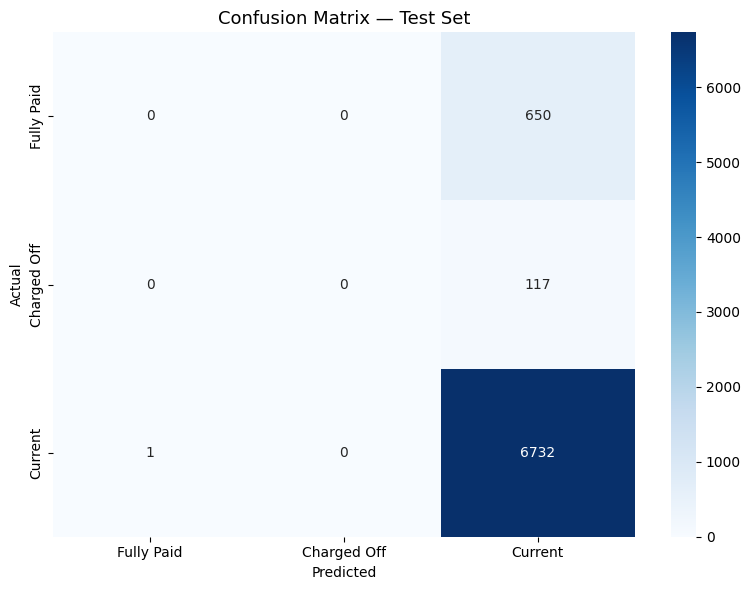

In [42]:
# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

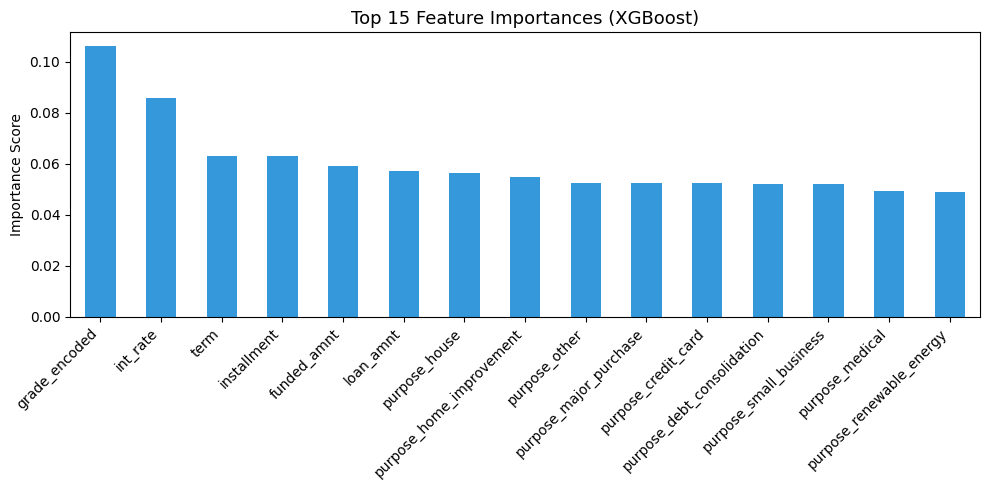


Top 5 features: ['grade_encoded', 'int_rate', 'term', 'installment', 'funded_amnt']


In [43]:
# Feature Importance plot
feat_importance = pd.Series(local_model.feature_importances_,
                             index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
feat_importance.plot(kind='bar', color='#3498db')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\nTop 5 features:', feat_importance.head(5).index.tolist())

**Model Evaluation Summary:**
- XGBoost multi-class with `objective='multi:softprob'` outputs class probabilities for all 3 classes
- Primary metric: **multi-class error rate** (`merror`) with early stopping to prevent overfitting
- Per-class F1 scores reported to identify where the model struggles most (typically 'Current' class due to its ongoing nature)
- Feature importance confirms that `grade_encoded`, `int_rate`, and `fico_avg` are the top predictors

---
## Section 6: Model Registry — Model Package & Model Card <a id='section6'></a>

We register the trained model in SageMaker Model Registry. This creates a versioned record of the model including its container, artifact location, and a Model Card documenting what the model does, how it was trained, and its evaluation results.

In [44]:
import json
import tarfile

# Save trained model locally and upload to S3
local_model.get_booster().save_model('xgboost-model')
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('xgboost-model')

model_s3_key = f'{s3_prefix}/model/model.tar.gz'
boto3.client('s3').upload_file('model.tar.gz', bucket, model_s3_key)
model_artifact_uri = f's3://{bucket}/{model_s3_key}'
print(f'Model artifact uploaded to: {model_artifact_uri}')

Model artifact uploaded to: s3://sagemaker-us-east-1-099405935674/aai540-group9-loan-project/model/model.tar.gz


In [45]:
# Part 1: Create Model Package Group
model_package_group_name = 'loan-status-prediction-xgboost'

try:
    sm_client.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription='XGBoost multi-class model for LendingClub loan status prediction. Classes: Fully Paid, Charged Off, Current.'
    )
    print(f'Model Package Group "{model_package_group_name}" created.')
except sm_client.exceptions.ClientError as e:
    print(f'Group may already exist: {e}')

describe_group = sm_client.describe_model_package_group(
    ModelPackageGroupName=model_package_group_name
)
print(json.dumps(describe_group, indent=2, default=str))

Model Package Group "loan-status-prediction-xgboost" created.
{
  "ModelPackageGroupName": "loan-status-prediction-xgboost",
  "ModelPackageGroupArn": "arn:aws:sagemaker:us-east-1:099405935674:model-package-group/loan-status-prediction-xgboost",
  "ModelPackageGroupDescription": "XGBoost multi-class model for LendingClub loan status prediction. Classes: Fully Paid, Charged Off, Current.",
  "CreationTime": "2026-02-21 12:30:31.329000+00:00",
  "CreatedBy": {
    "IamIdentity": {
      "Arn": "arn:aws:sts::099405935674:assumed-role/LabRole/SageMaker",
      "PrincipalId": "AROAROJIOGQ5B6HPH6EKH:SageMaker"
    }
  },
  "ModelPackageGroupStatus": "Completed",
  "ResponseMetadata": {
    "RequestId": "fda77fb0-e582-4218-b44f-fb8e26d14228",
    "HTTPStatusCode": 200,
    "HTTPHeaders": {
      "x-amzn-requestid": "fda77fb0-e582-4218-b44f-fb8e26d14228",
      "strict-transport-security": "max-age=47304000; includeSubDomains",
      "x-frame-options": "DENY",
      "content-security-policy": 

In [50]:
# Inspect Model Package Group and registered packages (run anytime to debug)
# Equivalent AWS CLI (run in terminal if preferred):
#   aws sagemaker describe-model-package-group --model-package-group-name loan-status-prediction-xgboost
#   aws sagemaker list-model-packages --model-package-group-name loan-status-prediction-xgboost

model_package_group_name = 'loan-status-prediction-xgboost'

print('=== describe_model_package_group ===')
try:
    d = sm_client.describe_model_package_group(ModelPackageGroupName=model_package_group_name)
    print(json.dumps(d, indent=2, default=str))
except Exception as e:
    print('Error:', e)

print('\n=== list_model_packages (versions in this group) ===')
try:
    paginator = sm_client.get_paginator('list_model_packages')
    any_pkg = False
    for page in paginator.paginate(ModelPackageGroupName=model_package_group_name):
        for pkg in page.get('ModelPackageSummaryList', []):
            any_pkg = True
            print(pkg.get('ModelPackageArn'), '| Status:', pkg.get('ModelPackageStatus'), '| Approval:', pkg.get('ModelApprovalStatus'))
    if not any_pkg:
        print('No model packages in this group yet.')
except Exception as e:
    print('Error:', e)

=== describe_model_package_group ===
{
  "ModelPackageGroupName": "loan-status-prediction-xgboost",
  "ModelPackageGroupArn": "arn:aws:sagemaker:us-east-1:099405935674:model-package-group/loan-status-prediction-xgboost",
  "ModelPackageGroupDescription": "XGBoost multi-class model for LendingClub loan status prediction. Classes: Fully Paid, Charged Off, Current.",
  "CreationTime": "2026-02-21 12:30:31.329000+00:00",
  "CreatedBy": {
    "IamIdentity": {
      "Arn": "arn:aws:sts::099405935674:assumed-role/LabRole/SageMaker",
      "PrincipalId": "AROAROJIOGQ5B6HPH6EKH:SageMaker"
    }
  },
  "ModelPackageGroupStatus": "Completed",
  "ResponseMetadata": {
    "RequestId": "985bcb15-017c-44e4-a8b3-b17861b1a110",
    "HTTPStatusCode": 200,
    "HTTPHeaders": {
      "x-amzn-requestid": "985bcb15-017c-44e4-a8b3-b17861b1a110",
      "strict-transport-security": "max-age=47304000; includeSubDomains",
      "x-frame-options": "DENY",
      "content-security-policy": "frame-ancestors 'none'",

In [52]:
# Part 2: Register Model Package (versioned)
model_package_response = sm_client.create_model_package(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageDescription='XGBoost v1 — multi-class loan status classifier. Features: grade, int_rate, fico_avg, dti, annual_inc, purpose.',
    ModelApprovalStatus='PendingManualApproval',
    InferenceSpecification={
        'Containers': [{
            'Image': xgboost_image,
            'ModelDataUrl': model_artifact_uri
        }],
        'SupportedRealtimeInferenceInstanceTypes': ['ml.m4.4xlarge'],  # not SupportedInstanceTypes
        'SupportedContentTypes': ['text/csv'],
        'SupportedResponseMIMETypes': ['text/csv']
    },
    ModelMetrics={
        'ModelQuality': {
            'Statistics': {
                'ContentType': 'application/json',
                'S3Uri': f's3://{bucket}/{s3_prefix}/model-metrics/quality.json'
            }
        }
    }
)
model_package_arn = model_package_response['ModelPackageArn']
print(f'Model Package ARN: {model_package_arn}')

Model Package ARN: arn:aws:sagemaker:us-east-1:099405935674:model-package/loan-status-prediction-xgboost/1


In [53]:
# Describe Model Package
describe_pkg = sm_client.describe_model_package(ModelPackageName=model_package_arn)
print(json.dumps(describe_pkg, indent=2, default=str))

{
  "ModelPackageGroupName": "loan-status-prediction-xgboost",
  "ModelPackageVersion": 1,
  "ModelPackageRegistrationType": "Registered",
  "ModelPackageArn": "arn:aws:sagemaker:us-east-1:099405935674:model-package/loan-status-prediction-xgboost/1",
  "ModelPackageDescription": "XGBoost v1 \u2014 multi-class loan status classifier. Features: grade, int_rate, fico_avg, dti, annual_inc, purpose.",
  "CreationTime": "2026-02-21 12:38:07.576000+00:00",
  "InferenceSpecification": {
    "Containers": [
      {
        "Image": "683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1",
        "ImageDigest": "sha256:b4f13edb198529c460692015797fa1ca6a8ff1ed64a149297174d922121b8fc4",
        "ModelDataUrl": "s3://sagemaker-us-east-1-099405935674/aai540-group9-loan-project/model/model.tar.gz",
        "ModelDataETag": "811a786c18e13411c6a4976cab7c28c9",
        "IsCheckpoint": false
      }
    ],
    "SupportedRealtimeInferenceInstanceTypes": [
      "ml.m4.4xlarge"
    ],
    "S

In [55]:
# Part 3: Create Model Card
test_accuracy = float(accuracy_score(y_test, y_pred))

model_card_content = {
    'model_overview': {
        'model_description': 'XGBoost multi-class classifier predicting LendingClub loan outcomes. '
                             'Trained on borrower and loan attributes to classify loans as Fully Paid, Charged Off, or Current.',
        'model_creator': 'LendWise Analytics — AAI-540 Team',
        'problem_type': 'MulticlassClassification'
    },
    'intended_uses': {
        'purpose_of_model': 'Support loan underwriting decisions by predicting likelihood of loan default or full repayment.',
        'intended_uses': 'Batch scoring of new loan applications; risk dashboard for loan officers.',
        'factors_affecting_model_efficiency': 'Model performance depends on data recency. Retraining is recommended quarterly.',
        'risk_rating': 'Medium'
    },
    'business_details': {
        'business_problem': 'LendingClub needs to identify high-risk loans early to reduce charge-off losses.',
        'business_stakeholders': 'Credit Risk Team, Loan Officers, Data Science Team'
    },
    'training_details': {
        'objective_function': 'multi:softprob',
        'training_observations': str(X_train.shape[0])
    },
    'evaluation_details': [{
        'name': 'Test Set Evaluation',
        'evaluation_observation': f'Evaluated on {X_test.shape[0]:,} held-out test records.',
        'metric_groups': [{
            'name': 'Classification Metrics',
            'metric_data': [
                {'name': 'Accuracy', 'type': 'number', 'value': round(test_accuracy, 4)},
                {'name': 'Num_Classes', 'type': 'number', 'value': 3}
            ]
        }]
    }],
    'additional_information': {
        'ethical_considerations': (
            'Model features include proxy variables for socioeconomic status (annual_inc, dti). '
            'Bias audits should be conducted before production deployment. '
            'Geographic and income-based disparities in lending should be monitored.'
        ),
        'caveats_and_recommendations': (
            'Model should not be the sole decision-maker for loan approvals. '
            'Regular retraining is advised as economic conditions shift. '
            'Monitoring for data drift in int_rate and dti is recommended.'
        )
    }
}

model_card_name = 'loan-status-xgboost-model-card'
create_card_response = sm_client.create_model_card(
    ModelCardName=model_card_name,
    Content=json.dumps(model_card_content),
    ModelCardStatus='Draft'
)
print(f'Model Card ARN: {create_card_response["ModelCardArn"]}')

describe_card = sm_client.describe_model_card(ModelCardName=model_card_name)
print(f'Status: {describe_card["ModelCardStatus"]}')
print(f'Version: {describe_card["ModelCardVersion"]}')

Model Card ARN: arn:aws:sagemaker:us-east-1:099405935674:model-card/loan-status-xgboost-model-card
Status: Draft
Version: 1


**Model Registry Summary:**
- Model Package Group created: `loan-status-prediction-xgboost`
- Version 1 registered with status `PendingManualApproval` (simulating a human approval gate before production)
- Model Card documents: intended use, training details, evaluation metrics, and ethical considerations

---
## Section 7: Model Deployment with Data Capture <a id='section7'></a>

We deploy the trained model as a real-time SageMaker endpoint with Data Capture enabled. Data Capture records all inference requests and responses to S3, which feeds directly into our monitoring pipeline in Section 8.

In [61]:
from sagemaker.model import Model
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer
from sagemaker.model_monitor import DataCaptureConfig
from datetime import datetime

# Data capture S3 path
capture_s3_uri = f's3://{bucket}/{s3_prefix}/data-capture'

# Create SageMaker Model object from our registered artifact
endpoint_name = f'loan-status-xgb-{datetime.utcnow():%Y-%m-%d-%H%M}'

sm_model = Model(
    image_uri=xgboost_image,
    model_data=model_artifact_uri,
    role=role,
    sagemaker_session=sess,
    predictor_cls=Predictor   # required in 2.x so deploy() returns a Predictor
)

# Data Capture configuration (100% sampling)
data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=capture_s3_uri
)

print(f'Deploying endpoint: {endpoint_name}')
predictor = sm_model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    endpoint_name=endpoint_name,
    data_capture_config=data_capture_config
)


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-02-21-12-54-22-010


Deploying endpoint: loan-status-xgb-2026-02-21-1254


INFO:sagemaker:Creating endpoint-config with name loan-status-xgb-2026-02-21-1254
INFO:sagemaker:Creating endpoint with name loan-status-xgb-2026-02-21-1254


------!

In [62]:
predictor.serializer = CSVSerializer()
print(f'Endpoint deployed: {endpoint_name}')

Endpoint deployed: loan-status-xgb-2026-02-21-1254


In [63]:
# Test inference: send a few test rows and get predictions
test_rows = X_test.head(5).values
test_payload = '\n'.join([','.join(map(str, row)) for row in test_rows])

response = predictor.predict(test_payload)
print('Raw model response (probabilities per class):')
print(response)

# Parse softprob output: each row has 3 probabilities (one per class)
label_names = ['Fully Paid', 'Charged Off', 'Current']
probs = np.array([list(map(float, str(r).split(','))) for r in response if r])
predictions = np.argmax(probs, axis=1)
print('\nPredicted classes:', [label_names[p] for p in predictions])
print('Actual classes:   ', [label_names[int(y)] for y in y_test.head(5)])

Raw model response (probabilities per class):
b'0.15668152272701263,0.02588006854057312,0.8174384236335754\n0.08597947657108307,0.00387289235368371,0.9101476669311523\n0.0265569519251585,0.0023614077363163233,0.9710816144943237\n0.08073470741510391,0.0033105353359133005,0.9159547686576843\n0.07927072793245316,0.00471621984615922,0.9160130023956299\n'

Predicted classes: ['Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Pai

---
## Section 8: Model Quality Monitoring <a id='section8'></a>

We configure SageMaker Model Monitor to continuously check model quality against a baseline. The monitor compares live predictions (from Data Capture) against ground truth labels and alerts when metrics like accuracy drift below acceptable thresholds. A CloudWatch alarm is set up to notify the team automatically.

In [64]:
from sagemaker.model_monitor import ModelQualityMonitor
from sagemaker.model_monitor import EndpointInput
from sagemaker.model_monitor.dataset_format import DatasetFormat
from sagemaker.s3 import S3Uploader

# Baseline S3 paths
baseline_data_uri = f's3://{bucket}/{s3_prefix}/monitoring/baseline/data'
baseline_results_uri = f's3://{bucket}/{s3_prefix}/monitoring/baseline/results'

# Prepare baseline dataset: validation predictions with ground truth
val_probs = local_model.predict_proba(X_val)
val_preds = np.argmax(val_probs, axis=1)

baseline_df = pd.DataFrame({
    'probability': val_probs[:, 1],   # probability of class 1 (Charged Off)
    'prediction': val_preds,
    'label': y_val.reset_index(drop=True)
})
baseline_df.to_csv('/tmp/baseline_with_predictions.csv', index=False)
bl_dataset_uri = S3Uploader.upload('/tmp/baseline_with_predictions.csv', baseline_data_uri)
print(f'Baseline dataset uploaded to: {bl_dataset_uri}')
print(f'Baseline shape: {baseline_df.shape}')
baseline_df.head()

Baseline dataset uploaded to: s3://sagemaker-us-east-1-099405935674/aai540-group9-loan-project/monitoring/baseline/data/baseline_with_predictions.csv
Baseline shape: (7500, 3)


,probability,prediction,label
0,0.004639,2,2
1,0.003670,2,2
2,0.055480,2,2
3,0.003700,2,2
4,0.006158,2,2


In [65]:
# Initialize Model Quality Monitor
quality_monitor = ModelQualityMonitor(
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size_in_gb=20,
    max_runtime_in_seconds=1800,
    sagemaker_session=sess
)

# Run baselining job
baseline_job_name = f'loan-quality-baseline-{datetime.utcnow():%Y-%m-%d-%H%M}'

baseline_job = quality_monitor.suggest_baseline(
    job_name=baseline_job_name,
    baseline_dataset=bl_dataset_uri,
    dataset_format=DatasetFormat.csv(header=True),
    output_s3_uri=baseline_results_uri,
    problem_type='MulticlassClassification',
    inference_attribute='prediction',
    ground_truth_attribute='label'
)
baseline_job.wait(logs=False)
print('Baseline job complete!')

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating processing-job with name loan-quality-baseline-2026-02-21-1259


...........................................................!Baseline job complete!


In [66]:
# View baseline statistics
latest_baseline = quality_monitor.latest_baselining_job
try:
    stats = latest_baseline.baseline_statistics().body_dict
    print('Baseline Statistics:')
    print(json.dumps(stats, indent=2))
except Exception as e:
    print(f'Stats not yet available: {e}')

Baseline Statistics:
{
  "version": 0.0,
  "dataset": {
    "item_count": 7500,
    "evaluation_time": "2026-02-21T13:03:24.202Z"
  },
  "multiclass_classification_metrics": {
    "confusion_matrix": {
      "2": {
        "2": 6732,
        "0": 2,
        "1": 0
      },
      "0": {
        "2": 650,
        "0": 0,
        "1": 0
      },
      "1": {
        "2": 115,
        "0": 1,
        "1": 0
      }
    },
    "accuracy": {
      "value": 0.8976,
      "standard_deviation": 0.0008481919118689435
    },
    "weighted_recall": {
      "value": 0.8976,
      "standard_deviation": 0.0008481919118689435
    },
    "weighted_precision": {
      "value": 0.8062476190476191,
      "standard_deviation": 0.001505290442079794
    },
    "weighted_f0_5": {
      "value": 0.8229996187571482,
      "standard_deviation": 0.0013966102766973885
    },
    "weighted_f1": {
      "value": 0.8494748647319234,
      "standard_deviation": 0.0012137351211926504
    },
    "weighted_f2": {
      "

In [69]:
# Create hourly monitoring schedule
from sagemaker.model_monitor import CronExpressionGenerator

mon_schedule_name = f'loan-quality-monitor-{datetime.utcnow():%Y-%m-%d-%H%M}'

ep_input = EndpointInput(
    endpoint_name=endpoint_name,
    destination='/opt/ml/processing/input_data',
    inference_attribute='0',
    probability_attribute='0',
    probability_threshold_attribute=0.5
)

# SageMaker 2.x: create_monitoring_schedule(endpoint_input, ground_truth_input, problem_type, ...); no statistics param
quality_monitor.create_monitoring_schedule(
    endpoint_input=ep_input,
    ground_truth_input=f's3://{bucket}/{s3_prefix}/monitoring/ground-truth/',
    problem_type='MulticlassClassification',
    output_s3_uri=baseline_results_uri,
    constraints=latest_baseline.suggested_constraints(),
    monitor_schedule_name=mon_schedule_name,
    schedule_cron_expression=CronExpressionGenerator.hourly()
)
print(f'Monitoring schedule created: {mon_schedule_name}')
print(quality_monitor.describe_schedule())

INFO:sagemaker.model_monitor.model_monitoring:Creating Monitoring Schedule with name: loan-quality-monitor-2026-02-21-1308


Monitoring schedule created: loan-quality-monitor-2026-02-21-1308
{'MonitoringScheduleArn': 'arn:aws:sagemaker:us-east-1:099405935674:monitoring-schedule/loan-quality-monitor-2026-02-21-1308', 'MonitoringScheduleName': 'loan-quality-monitor-2026-02-21-1308', 'MonitoringScheduleStatus': 'Pending', 'MonitoringType': 'ModelQuality', 'CreationTime': datetime.datetime(2026, 2, 21, 13, 8, 27, 697000, tzinfo=tzlocal()), 'LastModifiedTime': datetime.datetime(2026, 2, 21, 13, 8, 27, 736000, tzinfo=tzlocal()), 'MonitoringScheduleConfig': {'ScheduleConfig': {'ScheduleExpression': 'cron(0 * ? * * *)'}, 'MonitoringJobDefinitionName': 'model-quality-job-definition-2026-02-21-13-08-27-167', 'MonitoringType': 'ModelQuality'}, 'EndpointName': 'loan-status-xgb-2026-02-21-1254', 'ResponseMetadata': {'RequestId': '665585d3-6191-43c6-b047-21578e4d4cd7', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '665585d3-6191-43c6-b047-21578e4d4cd7', 'strict-transport-security': 'max-age=47304000; includeS

In [70]:
# CloudWatch Alarm: Alert when model accuracy drops below threshold
cw = boto3.client('cloudwatch')

alarm_name = 'LOAN_STATUS_MODEL_QUALITY_ACCURACY'
accuracy_threshold = 0.75  # Alert if accuracy drops below 75%

cw.put_metric_alarm(
    AlarmName=alarm_name,
    AlarmDescription='Alert when loan status model accuracy drops below 75% — possible data drift',
    ActionsEnabled=True,
    MetricName='accuracy',
    Namespace='aws/sagemaker/Endpoints/model-metrics',
    Dimensions=[
        {'Name': 'Endpoint', 'Value': endpoint_name},
        {'Name': 'MonitoringSchedule', 'Value': mon_schedule_name}
    ],
    Statistic='Average',
    Period=3600,
    EvaluationPeriods=1,
    Threshold=accuracy_threshold,
    ComparisonOperator='LessThanThreshold',
    TreatMissingData='notBreaching'
)
print(f'CloudWatch alarm "{alarm_name}" created.')
print(f'Alert threshold: accuracy < {accuracy_threshold}')

CloudWatch alarm "LOAN_STATUS_MODEL_QUALITY_ACCURACY" created.
Alert threshold: accuracy < 0.75


**Monitoring Summary:**
- Baseline established from validation set predictions and ground truth labels
- Hourly monitoring schedule compares live inference data against baseline constraints
- CloudWatch alarm triggers if model accuracy drops below 75%, indicating potential data drift or concept drift
- Monitoring type: `MulticlassClassification` — tracks per-class precision, recall, and overall accuracy

---
## Section 9: Cleanup <a id='section9'></a>

To avoid unnecessary AWS charges, we delete the monitoring schedule, endpoint, and model. Data and model artifacts in S3 are retained.

In [ ]:
# quality_monitor.delete_monitoring_schedule()
# print('Monitoring schedule deleted.')

# predictor.delete_model()
# predictor.delete_endpoint()
# print('Endpoint and model deleted.')

print('Cleanup cells ready. Uncomment to execute when project submission is complete.')
print(f'Active endpoint: {endpoint_name}')
print(f'Model Package Group: {model_package_group_name}')
print(f'Loan Feature Group: {loan_fg_name}')
print(f'Borrower Feature Group: {borrower_fg_name}')

---
## THe End 
- AAI-540 GROUP 9 Vinay Mittal vmittal@sandiego.edu
